In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
# 🔧 Hyperparameters
latent_dim = 100
image_size = 64
channels = 3
batch_size = 128
lr = 0.0002
epochs = 100
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 📸 Transform & Load Dataset (CelebA assumed)
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

dataset = torchvision.datasets.CelebA(root='./data', split='train', transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [24]:
# 🎨 Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            self._block(latent_dim, 512, 4, 1, 0),
            self._block(512, 256, 4, 2, 1),
            self._block(256, 128, 4, 2, 1),
            self._block(128, 64, 4, 2, 1),
            nn.ConvTranspose2d(64, channels, 4, 2, 1),
            nn.Tanh()
        )

    def _block(self, in_ch, out_ch, k, s, p):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, k, s, p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(True)
        )

    def forward(self, z):
        return self.net(z)

# 🕵️ Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            self._block(channels, 64, 4, 2, 1, bn=False),
            self._block(64, 128, 4, 2, 1),
            self._block(128, 256, 4, 2, 1),
            self._block(256, 512, 4, 2, 1),
            nn.Conv2d(512, 1, 4, 1, 0),
            nn.Sigmoid()
        )

    def _block(self, in_ch, out_ch, k, s, p, bn=True):
        layers = [nn.Conv2d(in_ch, out_ch, k, s, p, bias=False)]
        if bn: layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        return nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [25]:
# 🎯 Initialize
G = Generator().to(device)
D = Discriminator().to(device)

# 🧠 Loss and Optimizers
criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))


In [26]:
# 🎞️ Training Loop
for epoch in range(epochs):
    for real, _ in dataloader:
        real = real.to(device)
        bs = real.size(0)

        # === Train Discriminator ===
        z = torch.randn(bs, latent_dim, 1, 1).to(device)
        fake = G(z)

        D_real = D(real).view(-1)
        D_fake = D(fake.detach()).view(-1)

        loss_D = criterion(D_real, torch.ones_like(D_real)) + \
                 criterion(D_fake, torch.zeros_like(D_fake))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # === Train Generator ===
        output = D(fake).view(-1)
        loss_G = criterion(output, torch.ones_like(output))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1}/{epochs} | Loss D: {loss_D:.4f}, Loss G: {loss_G:.4f}")

NameError: name 'dataloader' is not defined

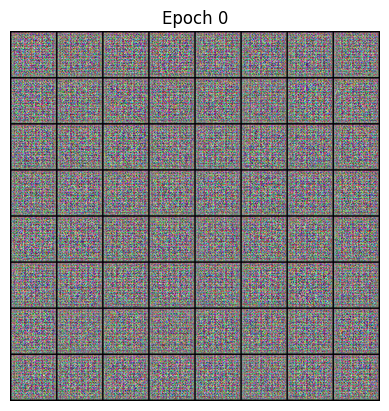

In [27]:
    # Save sample
    if epoch % 10 == 0:
        with torch.no_grad():
            z = torch.randn(64, latent_dim, 1, 1).to(device)
            samples = G(z).detach().cpu()
        grid = torchvision.utils.make_grid(samples, nrow=8, normalize=True)
        plt.imshow(grid.permute(1, 2, 0))
        plt.title(f"Epoch {epoch}")
        plt.axis('off')
        plt.show()